<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">


# Train-Test Split and Cross-Validation Lab 


## Review of Train/Test Validation Methods

We've discussed overfitting, underfitting, and how to validate the "generalizeability" of your models by testing them on unseen data. 

In this lab you'll practice two related validation methods: 
1. **train/test split**
2. **k-fold cross-validation**

Train/test split and k-fold cross-validation both serve two useful purposes:
- We prevent overfitting by not using all the data, and
- We retain some remaining data to evaluate our model.

In the case of cross-validation, the model fitting and evaluation is performed multiple times on different train/test splits of the data.

Ultimately we can use the training/test validation framework to compare multiple models on the same dataset. This could be comparisons of two linear models, or of completely different models on the same data.


## Instructions

For your independent practice, fit **three different models** on the Boston Housing Data. For example, you could pick three different subsets of variables, one or more polynomial models, or any other model that you like. 

**Start with train/test split validation:**
* Fix a testing/training split of the data.
* Train each of your models on the training data.
* Evaluate each of the models on the testing data.
* Rank the models by how well they score on the testing data set.

**Then try k-fold cross-validation:**
* Perform a k-fold cross-validation and use the cross-validation scores to compare your models. Did this change your rankings?
* Try a few different k-splits of the data for the same models.

If you're interested, try a variety of response variables. We start with **PRICE** (the `.target` attribute from the data set load method).

In [3]:
from matplotlib import pyplot as plt

import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score

from sklearn import datasets

# %config InlineBackend.figure_format = 'retina'
# %matplotlib inline

# plt.style.use('fivethirtyeight')


In [10]:
# Load the Boston Housing dataset
data = pd.read_csv('BostonHousing2.csv')
df = data.copy()
df['PRICE'] = df['PRICE'].astype(float)
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
# No code here please


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [11]:
# your code here
# what is the shape of the dataframe?
df.shape

(506, 14)

In [3]:
# No code here please

(506, 14)

### 1) Clean up any data problems.

Fix any problems with the data, if applicable.

In [12]:
# your code here
# any missing data?
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [8]:
# No code here please

# There is no missing data as per the result

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [13]:
# your code here
# Get overview of your data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [9]:
# No code here please



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [14]:
# your code here
# Get the max for each column
df.max(numeric_only=True)

CRIM        88.9762
ZN         100.0000
INDUS       27.7400
CHAS         1.0000
NOX          0.8710
RM           8.7800
AGE        100.0000
DIS         12.1265
RAD         24.0000
TAX        711.0000
PTRATIO     22.0000
B          396.9000
LSTAT       37.9700
PRICE       50.0000
dtype: float64

In [10]:
# No code here please


CRIM        88.9762
ZN         100.0000
INDUS       27.7400
CHAS         1.0000
NOX          0.8710
RM           8.7800
AGE        100.0000
DIS         12.1265
RAD         24.0000
TAX        711.0000
PTRATIO     22.0000
B          396.9000
LSTAT       37.9700
PRICE       50.0000
dtype: float64

In [15]:
# your code here
# Get the min for each column
df.min(numeric_only=True)

CRIM         0.00632
ZN           0.00000
INDUS        0.46000
CHAS         0.00000
NOX          0.38500
RM           3.56100
AGE          2.90000
DIS          1.12960
RAD          1.00000
TAX        187.00000
PTRATIO     12.60000
B            0.32000
LSTAT        1.73000
PRICE        5.00000
dtype: float64

In [11]:
# No code here please


CRIM         0.00632
ZN           0.00000
INDUS        0.46000
CHAS         0.00000
NOX          0.38500
RM           3.56100
AGE          2.90000
DIS          1.12960
RAD          1.00000
TAX        187.00000
PTRATIO     12.60000
B            0.32000
LSTAT        1.73000
PRICE        5.00000
dtype: float64

### 2) Select 3–4 variables with your data set on which to perform a 50-50 train/test split.

- Use scikit-learn.
- Score and plot your predictions.

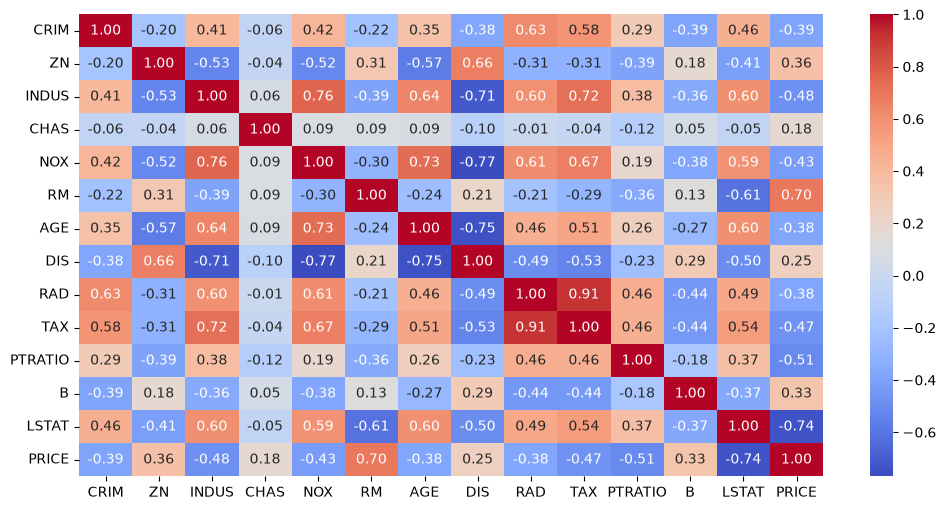

In [16]:
# your code here
# get correlation in corr and do a correlation heatmap.
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

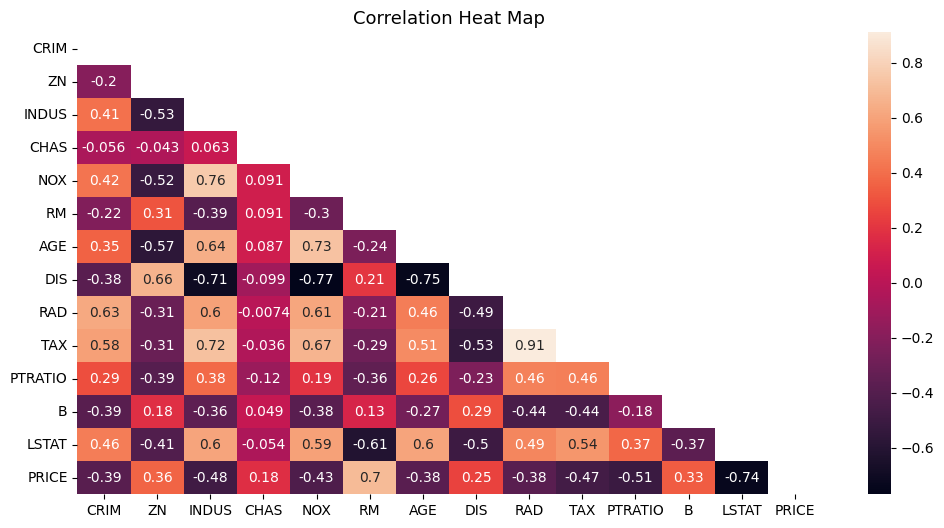

In [12]:
# No code here please



 Separate `RM, LSTAT ,INDUS` into X.

In [17]:
# your code here
#X = .......?
X = df[['RM', 'LSTAT', 'INDUS']]

# display head of X
X.head()

,RM,LSTAT,INDUS
0,6.575,4.98,2.31
1,6.421,9.14,7.07
2,7.185,4.03,7.07
3,6.998,2.94,2.18
4,7.147,5.33,2.18


In [13]:
# No code here please


,RM,LSTAT,INDUS
0,6.575,4.98,2.31
1,6.421,9.14,7.07
2,7.185,4.03,7.07
3,6.998,2.94,2.18
4,7.147,5.33,2.18


- Set the target y to be the column PRICE

In [18]:
# set the target
y = df['PRICE']
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: PRICE, dtype: float64

In [15]:
# No code here please


0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: PRICE, Length: 506, dtype: float64

#### split the data using train_test_split, start with 50-50 split.
Also try different parameters. <shift+tab> for doc string 

In [19]:
# your code here
#perform a 50-50 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [20]:
# check the shape of your train and test sets!
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(253, 3) (253,)
(253, 3) (253,)


In [18]:
# No code here please



(253, 3) (253,)
(253, 3) (253,)


In [21]:
# Instantiate model, call it slr
slr = LinearRegression()

# fit the instance on train set
slr.fit(X_train, y_train)


# get predictions and add as a new column 'PRICE_predict' into your dataframe
df['PRICE_predict'] = slr.predict(X)


# print the train and test scores
print(f"Score for the training is: {slr.score(X_train, y_train)}")
print(f"Score for the test is: {slr.score(X_test, y_test)}")


# Add 'residual' column into your dataframe. Calculate it manually
df['residual'] = df['PRICE'] - df['PRICE_predict']

Score for the training is: 0.6689399942738492
Score for the test is: 0.60311950087538


In [20]:
# NO CODE HERE

df.head(5)   # notice the 'PRICE_predict' and 'residual'  columns


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE,PRICE_predict,residual
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,29.497348,-5.497348
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,25.834846,-4.234846
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,32.131382,2.568618
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,32.552968,0.847032
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,31.860942,4.339058


### 3) Repeat the above process with 70-30 and 90-10 splits.

- Score and plot.  
- What do you learn?

In [22]:
# with 70 - 30 split (start your namings with X2 and y2)
X2_train, X2_test, y2_train, y2_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
# check the shape of training and testing for both X and y
print(X2_train.shape, y2_train.shape)
print(X2_test.shape, y2_test.shape)

(354, 3) (354,)
(152, 3) (152,)


In [22]:
# NO CODE HERE



(354, 3) (354,)
(152, 3) (152,)


In [24]:
# Instantiate model, call it slr2
slr2 = LinearRegression()

# fit the instance on train set
slr2.fit(X2_train, y2_train)


# get predictions and add as a new column 'PRICE_predict2' into your dataframe
df['PRICE_predict2'] = slr2.predict(X)


# get the train and test scores
print(f"Score for the training is: {slr2.score(X2_train, y2_train)}")
print(f"Score for the test is: {slr2.score(X2_test, y2_test)}")

Score for the training is: 0.6487385786896802
Score for the test is: 0.6019543580919948


In [25]:
# Do 90 - 10 split (start your namings with X3 and y3)
X3_train, X3_test, y3_train, y3_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [26]:
# check the shape of your train and test sets!
print(X3_train.shape, y3_train.shape)
print(X3_test.shape, y3_test.shape)

(455, 3) (455,)
(51, 3) (51,)


In [25]:
# NO CODE HERE PLEASE



(455, 3) (455,)
(51, 3) (51,)


In [27]:
# your code here
# Instantiate model, call it slr3
slr3 = LinearRegression()

# fit the instance on train set
slr3.fit(X3_train, y3_train)


# get predictions and add as a new column 'PRICE_predict3' into your dataframe
df['PRICE_predict3'] = slr3.predict(X)


# get the train and test scores
print(f"Score for the training is: {slr3.score(X3_train, y3_train)}")
print(f"Score for the test is: {slr3.score(X3_test, y3_test)}")

Score for the training is: 0.6348613652695104
Score for the test is: 0.686693751748722


In [28]:
# your code here
# print the score for each model for both training and testing
print(f"Score for 50-50 training is: {slr.score(X_train, y_train)}")
print(f"Score for 50-50 test is: {slr.score(X_test, y_test)}")
print()
print(f" Score for 70-30 training is: {slr2.score(X2_train, y2_train)}")
print(f"Score for 70-30 test is: {slr2.score(X2_test, y2_test)}")
print()
print(f" Score for 90-10 training is: {slr3.score(X3_train, y3_train)}")
print(f"Score for 90-10 test is: {slr3.score(X3_test, y3_test)}")

Score for 50-50 training is: 0.6689399942738492
Score for 50-50 test is: 0.60311950087538

 Score for 70-30 training is: 0.6487385786896802
Score for 70-30 test is: 0.6019543580919948

 Score for 90-10 training is: 0.6348613652695104
Score for 90-10 test is: 0.686693751748722


In [27]:
# NO CODE HERE PLEASE
# Note: your result may be different than the below result





Score for 50-50 training is: 0.6444167000808319
Score for 50-50 test is: 0.625996595648338

 Score for 70-30 training is: 0.6114110572311812
Score for 70-30 test is: 0.6856631640613768

 Score for 90-10 training is: 0.6337726546654995
Score for 90-10 test is: 0.6854817797677495


### 4) Try k-folds cross-validation with k between 5–10 for your regression. 

- What seems optimal? 
- How do your scores change?  
- Try out different folds to get a sense of how this impacts your score.


In [29]:
# your code here
# Perform 5-19 fold cross validation and print the scores mean of each fold
# Hint: use for loop with range
for k in range(5, 20):
    kf = KFold(n_splits=k, shuffle=False)
    scores = cross_val_score(LinearRegression(), X, y, cv=kf)
    print(f"{k} -fold Mean Cross-validated scores: {scores.mean()}")

5 -fold Mean Cross-validated scores: 0.27216237650945374
6 -fold Mean Cross-validated scores: 0.31423453734636153
7 -fold Mean Cross-validated scores: 0.2895542157978464
8 -fold Mean Cross-validated scores: 0.18788747298812622
9 -fold Mean Cross-validated scores: 0.2126786614050018
10 -fold Mean Cross-validated scores: -0.05984279424821335
11 -fold Mean Cross-validated scores: -0.07288640345001768
12 -fold Mean Cross-validated scores: 0.05185877964074351
13 -fold Mean Cross-validated scores: -0.06182032758529903
14 -fold Mean Cross-validated scores: 0.11521124489362965
15 -fold Mean Cross-validated scores: -0.12625725572815094
16 -fold Mean Cross-validated scores: 0.06538043865224223
17 -fold Mean Cross-validated scores: -0.058071075140162784
18 -fold Mean Cross-validated scores: -0.08545435276537722
19 -fold Mean Cross-validated scores: -0.08492104740877593


In [29]:
# NO CODE HERE PLEASE







5 -fold Mean Cross-validated scores: 0.2721623765094543
6 -fold Mean Cross-validated scores: 0.3142345373463616
7 -fold Mean Cross-validated scores: 0.2895542157978465
8 -fold Mean Cross-validated scores: 0.18788747298812644
9 -fold Mean Cross-validated scores: 0.21267866140500172
10 -fold Mean Cross-validated scores: -0.05984279424821346
11 -fold Mean Cross-validated scores: -0.07288640345001852
12 -fold Mean Cross-validated scores: 0.05185877964074329
13 -fold Mean Cross-validated scores: -0.06182032758529849
14 -fold Mean Cross-validated scores: 0.11521124489362965
15 -fold Mean Cross-validated scores: -0.12625725572815108
16 -fold Mean Cross-validated scores: 0.06538043865224169
17 -fold Mean Cross-validated scores: -0.058071075140162826
18 -fold Mean Cross-validated scores: -0.08545435276537733
19 -fold Mean Cross-validated scores: -0.08492104740877611


In [30]:
# your code here
# Perform 5-19 fold cross validation
# use KFold to shuffle the data - does the result changes?
for k in range(5, 20):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(LinearRegression(), X, y, cv=kf)
    print(f"{k} -fold Mean Cross-validated scores: {scores.mean()}")

5 -fold Mean Cross-validated scores: 0.6228152552527687
6 -fold Mean Cross-validated scores: 0.6261686220007884
7 -fold Mean Cross-validated scores: 0.6245990433486328
8 -fold Mean Cross-validated scores: 0.6245378440132374
9 -fold Mean Cross-validated scores: 0.6116842438364944
10 -fold Mean Cross-validated scores: 0.6241088887560651
11 -fold Mean Cross-validated scores: 0.6225937513010907
12 -fold Mean Cross-validated scores: 0.6176773456334844
13 -fold Mean Cross-validated scores: 0.6101693282742514
14 -fold Mean Cross-validated scores: 0.624725197840692
15 -fold Mean Cross-validated scores: 0.6238168579659374
16 -fold Mean Cross-validated scores: 0.5972032370895336
17 -fold Mean Cross-validated scores: 0.6253447976820667
18 -fold Mean Cross-validated scores: 0.6075435143199925
19 -fold Mean Cross-validated scores: 0.6165774207527313


In [30]:
# NO CODE HERE PLEASE





5 -fold Mean Cross-validated scores: 0.6279248609998469
6 -fold Mean Cross-validated scores: 0.6218923877181085
7 -fold Mean Cross-validated scores: 0.6094497041637349
8 -fold Mean Cross-validated scores: 0.6139184661257469
9 -fold Mean Cross-validated scores: 0.5992558002615535
10 -fold Mean Cross-validated scores: 0.6234837355036905
11 -fold Mean Cross-validated scores: 0.6041012269944382
12 -fold Mean Cross-validated scores: 0.6103682865047042
13 -fold Mean Cross-validated scores: 0.5987598877274162
14 -fold Mean Cross-validated scores: 0.6165867056848183
15 -fold Mean Cross-validated scores: 0.6039985922213842
16 -fold Mean Cross-validated scores: 0.6088238803503652
17 -fold Mean Cross-validated scores: 0.5891289453486923
18 -fold Mean Cross-validated scores: 0.5822342074551123
19 -fold Mean Cross-validated scores: 0.6011241925008676


#### does the result changes after shuffle?

> your answer here : Yes, the results change significantly after shuffling. Without shuffling, some folds have very low or even negative R² scores because the data has an inherent order that creates uneven splits. Shuffling ensures each fold gets a representative sample, producing much more consistent and reliable scores. This shows that shuffling is important in cross-validation when data may have structure based on its original ordering.